# Plot carbonate sensitivity

In [1]:
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
from matplotlib.lines import Line2D

In [4]:
import numpy as np

In [5]:
import cftime

In [6]:
import pop_tools

/global/common/software/m4632/conda/cworthy/lib/python3.11/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## ROMS

In [7]:
from roms_tools import Grid, ROMSOutput

ERROR 1: PROJ: proj_create_from_database: Open of /global/common/software/m4632/conda/cworthy/share/proj failed


In [8]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-08-06 23:53:28 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-08-06 23:53:28 - INFO - Total time: 0.003 seconds
2026-08-06 23:53:28 - INFO - ================================================================================================


In [9]:
roms_output = ROMSOutput(
    grid=grid,
    path=f"roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_200001.nc", 
    use_dask=True
)

2026-08-06 23:53:28 - WARNING - Dataset is missing attribute 'theta_s'. Skipping this check.
2026-08-06 23:53:28 - WARNING - Dataset is missing attribute 'theta_b'. Skipping this check.
2026-08-06 23:53:28 - WARNING - Dataset is missing attribute 'hc'. Skipping this check.
2026-08-06 23:53:28 - WARNING - Dataset is missing attribute 'Cs_r'. Skipping this check.
2026-08-06 23:53:28 - WARNING - Dataset is missing attribute 'Cs_w'. Skipping this check.


In [10]:
roms_output.ds

<xarray.Dataset> Size: 921MB
Dimensions:     (time: 31, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time        (time) datetime64[ns] 248B NaT NaT NaT NaT ... NaT NaT NaT NaT
    lat_rho     (eta_rho, xi_rho) float64 14MB ...
    lon_rho     (eta_rho, xi_rho) float64 14MB ...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ocean_time  (time) float64 248B dask.array<chunksize=(1,), meta=np.ndarray>
    dDICdCO2    (time, eta_rho, xi_rho) float64 439MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    dDICdALK    (time, eta_rho, xi_rho) float64 439MB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    mask_rho    (eta_rho, xi_rho) float64 14MB ...

In [11]:
dDICdCO2_roms = roms_output.ds.dDICdCO2.isel(time=0).compute()
dDICdALK_roms = roms_output.ds.dDICdALK.isel(time=0).compute()

## CESM

In [12]:
grid_cesm = pop_tools.get_grid("POP_gx1v7")

In [13]:
ds_cesm = xr.open_dataset("/global/cfs/projectdirs/m4746/Projects/OAE-Efficiency-Map/data/carbonate-sensitivities/carbonate_sensitivity_daily.nc")

In [14]:
dDICdCO2_cesm = ds_cesm.sel(time=cftime.DatetimeNoLeap(348, 1, 1, 12, 0, 0, 0, has_year_zero=True)).dDICdCO2
dDICdALK_cesm = ds_cesm.sel(time=cftime.DatetimeNoLeap(348, 1, 1, 12, 0, 0, 0, has_year_zero=True)).dDICdALK

## Colorbar ranges

### $\beta$

In [15]:
vmin_beta = 2
vmax_beta = 30

### $\eta$

In [16]:
vmin_eta = 0.77
vmax_eta = 0.95

## Plotting

In [17]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [18]:
locations = {
    "J": {
        "release_center": {"eta_rho": 710, "xi_rho": 459},
        "color": "#df65b0"
    },    
    "V": {
        "release_center": {"eta_rho": 855, "xi_rho": 1135},
        "color": "#4CAF50"
    },
    "B": {
        "release_center": {"eta_rho": 650, "xi_rho": 1290},
        "color": "#2196F3"
    },
    "E": {
        "release_center": {"eta_rho": 490, "xi_rho": 1640},
        "color": "#FFA500"
    }
} 

In [19]:
def _add_locations(ax):
    for loc in locations:
        eta_rho = locations[loc]["release_center"]["eta_rho"]
        xi_rho = locations[loc]["release_center"]["xi_rho"]
        lon = grid.ds["lon_rho"][eta_rho, xi_rho].item()
        lat = grid.ds["lat_rho"][eta_rho, xi_rho].item()
        color = locations[loc]["color"]

        ax.plot(lon, lat, marker='o', color='none', markerfacecolor=color, markersize=8, transform=ccrs.PlateCarree())
    
    colors = [loc["color"] for loc in locations.values()]
    proxies = [Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markersize=8) for color in colors]
    
    ax.legend(
        proxies,
        list(locations.keys()),
        loc="upper right",
        bbox_to_anchor=(1, 1.01),
        ncol=1,
        framealpha=1
    )

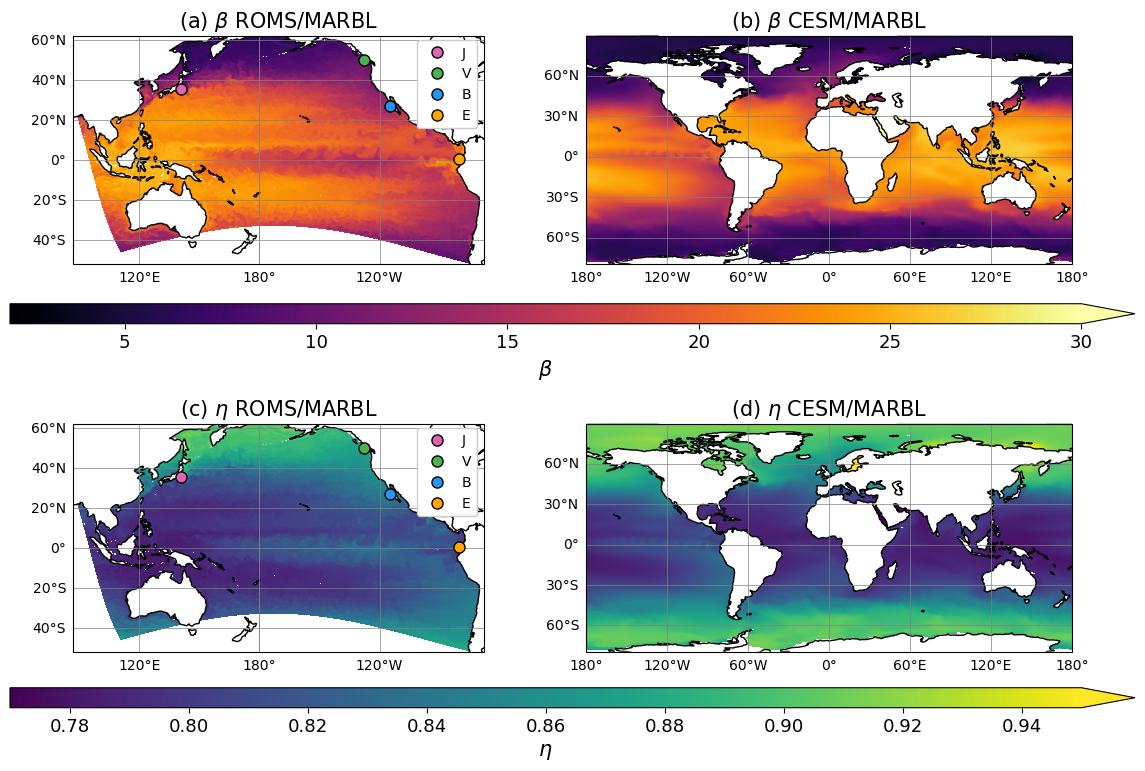

In [48]:
fig = plt.figure(figsize=(15, 8))
cmap_eta, cmap_beta = plt.get_cmap("viridis").copy(), plt.get_cmap("inferno").copy()

proj_roms = ccrs.PlateCarree(central_longitude=180)
proj_cesm = ccrs.PlateCarree(central_longitude=0)

plots_cfg = [
    (221, proj_roms, grid.ds["lon_rho"], grid.ds["lat_rho"], dDICdCO2_roms, cmap_beta, vmin_beta, vmax_beta, r"(a) $\beta$ ROMS/MARBL"),
    (222, proj_cesm, grid_cesm.TLONG, grid_cesm.TLAT, dDICdCO2_cesm.where(grid_cesm.KMT > 0), cmap_beta, vmin_beta, vmax_beta, r"(b) $\beta$ CESM/MARBL"),
    (223, proj_roms, grid.ds["lon_rho"], grid.ds["lat_rho"], dDICdALK_roms, cmap_eta, vmin_eta, vmax_eta, r"(c) $\eta$ ROMS/MARBL"),
    (224, proj_cesm, grid_cesm.TLONG, grid_cesm.TLAT, dDICdALK_cesm.where(grid_cesm.KMT > 0), cmap_eta, vmin_eta, vmax_eta, r"(d) $\eta$ CESM/MARBL"),
]

pmeshes, axes = [], []
for pos, proj, lon, lat, data, cmap, vmin, vmax, title in plots_cfg:
    ax = fig.add_subplot(pos, projection=proj)
    p = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=15)
    _add_coastlines_and_gridlines(ax)
    pmeshes.append(p)
    axes.append(ax)

# Restrict extent & add locations for ROMS panels (left column)
lon_min, lon_max = -93, 112
for ax in [axes[0], axes[2]]:
    lat_min, lat_max = ax.get_extent(crs=proj_roms)[2:]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj_roms)
    _add_locations(ax)

# Colorbar below each row
for p, label, y in [(pmeshes[0], r"$\beta$", 0.52), (pmeshes[2], r"$\eta$", 0.04)]:
    cbar_ax = fig.add_axes([0.15, y, 0.75, 0.025])
    cbar = fig.colorbar(p, cax=cbar_ax, extend="max", orientation="horizontal", label=label)
    cbar.set_label(label, fontsize=15)
    cbar.ax.tick_params(labelsize=13)

fig.subplots_adjust(hspace=0.7, wspace=-0.1)

In [49]:
fig.savefig(
    "figures/carbonate_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)